# Dự án Dữ liệu - Phân tích Thị trường Chứng khoán

Dữ liệu chuỗi thời gian (Time Series) là một chuỗi các điểm dữ liệu được lập chỉ mục theo thứ tự thời gian. Dữ liệu chuỗi thời gian có mặt ở khắp mọi nơi, vì vậy việc xử lý chúng là kỹ năng quan trọng đối với bất kỳ nhà phân tích dữ liệu hay nhà khoa học dữ liệu nào.

Trong notebook này, chúng ta sẽ khám phá dữ liệu từ thị trường chứng khoán, cụ thể là một số cổ phiếu công nghệ (Apple, Amazon, Google và Microsoft). Chúng ta sẽ học cách sử dụng thư viện `yfinance` để lấy thông tin cổ phiếu và trực quan hóa các khía cạnh khác nhau bằng Seaborn và Matplotlib. Chúng ta cũng sẽ xem xét một vài cách phân tích rủi ro của cổ phiếu dựa trên lịch sử hiệu suất trước đó. Cuối cùng, chúng ta sẽ dự đoán giá cổ phiếu trong tương lai thông qua phương pháp Long Short Term Memory (LSTM)!

Chúng ta sẽ lần lượt trả lời các câu hỏi sau:

1.) Sự thay đổi giá cổ phiếu theo thời gian như thế nào?
2.) Tỷ suất lợi nhuận hàng ngày trung bình của cổ phiếu là bao nhiêu?
3.) Đường trung bình động (moving average) của các cổ phiếu khác nhau là gì?
4.) Mối tương quan giữa các cổ phiếu khác nhau như thế nào?
5.) Chúng ta chịu rủi ro bao nhiêu khi đầu tư vào một cổ phiếu cụ thể?
6.) Làm thế nào để dự đoán hành vi cổ phiếu trong tương lai? (Dự đoán giá đóng cửa của Apple Inc bằng LSTM)

## Giới thiệu về Bộ Dữ liệu

Bộ dữ liệu mà chúng ta đang sử dụng chứa thông tin lịch sử về giá cổ phiếu của bốn công ty công nghệ lớn: Apple (AAPL), Google (GOOG), Microsoft (MSFT), và Amazon (AMZN).

Dữ liệu được thu thập bằng thư viện `yfinance` và bao gồm các thông tin sau cho mỗi ngày giao dịch:

*   **Open (Giá mở cửa):** Giá của cổ phiếu khi thị trường mở cửa vào một ngày cụ thể.
*   **High (Giá cao nhất):** Giá cao nhất mà cổ phiếu đạt được trong ngày giao dịch.
*   **Low (Giá thấp nhất):** Giá thấp nhất mà cổ phiếu đạt được trong ngày giao dịch.
*   **Close (Giá đóng cửa):** Giá cuối cùng của cổ phiếu khi thị trường đóng cửa vào một ngày cụ thể.
*   **Volume (Khối lượng):** Tổng số cổ phiếu được giao dịch trong ngày.
*   **Adjusted Close (Giá đóng cửa đã điều chỉnh):** Giá đóng cửa của cổ phiếu được điều chỉnh cho các sự kiện của công ty như chia tách cổ phiếu, cổ tức và phát hành quyền.

Dữ liệu này cung cấp cái nhìn chi tiết về biến động giá và hoạt động giao dịch của các cổ phiếu này trong một khoảng thời gian nhất định, cho phép chúng ta thực hiện các phân tích như xu hướng giá, lợi nhuận hàng ngày, đường trung bình động và dự đoán tương lai.

# 1. Sự thay đổi giá cổ phiếu theo thời gian như thế nào?

Trong phần này, chúng ta sẽ tìm hiểu cách xử lý các yêu cầu thông tin cổ phiếu bằng pandas và cách phân tích các thuộc tính cơ bản của một cổ phiếu.

In [ ]:
!pip install -q yfinance

!pip install --upgrade yfinance pandas_datareader


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.8/137.8 kB 8.5 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.66
    Uninstalling yfinance-0.2.66:
      Successfully uninstalled yfinance-0.2.66


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

import yfinance as yf
from datetime import datetime

tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']
company_name = ["APPLE", "GOOGLE", "MICROSOFT", "AMAZON"]

end = datetime.now()
start = datetime(end.year - 1, end.month, end.day)

# Download data and fix column names for easier concat
company_list = []
for stock, com_name in zip(tech_list, company_name):
    data = yf.download(stock, start, end)
    # Flatten MultiIndex if it exists
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data["company_name"] = com_name
    globals()[stock] = data
    company_list.append(data)

df = pd.concat(company_list, axis=0)
display(df.tail(10))

/tmp/ipykernel_2640/2866854747.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2640/2866854747.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2640/2866854747.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2640/2866854747.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,company_name
Date,,,,,,
2026-05-15,264.140015,264.359985,260.890015,262.500000,40770300,AMAZON
2026-05-18,264.859985,268.850006,262.529999,263.869995,33690800,AMAZON
2026-05-19,259.339996,262.250000,255.190002,262.040009,40340700,AMAZON
2026-05-20,265.010010,265.579987,259.529999,260.049988,34933200,AMAZON
2026-05-21,268.459991,269.489990,261.369995,263.500000,36591700,AMAZON
2026-05-22,266.320007,269.790009,266.239990,268.660004,27535500,AMAZON
2026-05-26,265.290009,269.299988,262.070007,267.940002,38028100,AMAZON
2026-05-27,271.850006,272.410004,265.700012,266.149994,40061900,AMAZON
2026-05-28,274.000000,274.500000,267.440002,272.269989,40630400,AMAZON


Xem xét nội dung dữ liệu, chúng ta có thể thấy dữ liệu là dạng số và ngày tháng là chỉ mục (index). Lưu ý rằng các ngày cuối tuần không có trong hồ sơ.

**Ghi chú nhanh:** Sử dụng `globals()` là một cách khá tùy tiện để đặt tên `DataFrame`, nhưng nó đơn giản. Bây giờ đã có dữ liệu, hãy thực hiện một số phân tích cơ bản và kiểm tra dữ liệu của chúng ta.

## Thống kê mô tả về dữ liệu
Phương thức `.describe()` tạo ra các thống kê mô tả bao gồm tóm tắt về xu hướng trung tâm, độ phân tán và hình dạng phân phối của tập dữ liệu, loại bỏ các giá trị `NaN`.

In [ ]:
# Summary Stats
AAPL.describe()

Price,Close,High,Low,Open,Volume
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,251.628883,254.026261,249.161049,251.437977,4.952386e+07
std,27.854999,27.943530,27.499265,27.597607,1.870001e+07
min,194.866928,196.789286,194.299165,195.165722,1.791060e+07
25%,231.589813,232.968419,228.892442,231.168489,3.939210e+07
50%,257.761078,259.619176,254.809116,257.417288,4.566225e+07
75%,270.942505,273.459050,268.273822,271.053833,5.269068e+07
max,312.510010,315.000000,309.570007,311.779999,1.637413e+08


Chúng ta chỉ có khoảng 250-255 bản ghi trong một năm vì các ngày cuối tuần không được bao gồm trong dữ liệu chứng khoán.

## Thông tin về dữ liệu
Phương thức `.info()` in ra thông tin về DataFrame bao gồm kiểu dữ liệu của chỉ mục và các cột, số lượng giá trị không rỗng (non-null) và mức sử dụng bộ nhớ.

In [ ]:
# General info
AAPL.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2025-06-02 to 2026-05-29
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         250 non-null    float64
 1   High          250 non-null    float64
 2   Low           250 non-null    float64
 3   Open          250 non-null    float64
 4   Volume        250 non-null    int64  
 5   company_name  250 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 13.7+ KB


## Giá đóng cửa (Closing Price)

Giá đóng cửa là mức giá cuối cùng mà cổ phiếu được giao dịch trong ngày giao dịch chính thức. Giá đóng cửa của một cổ phiếu là chuẩn mực tiêu chuẩn được các nhà đầu tư sử dụng để theo dõi hiệu suất của nó theo thời gian.

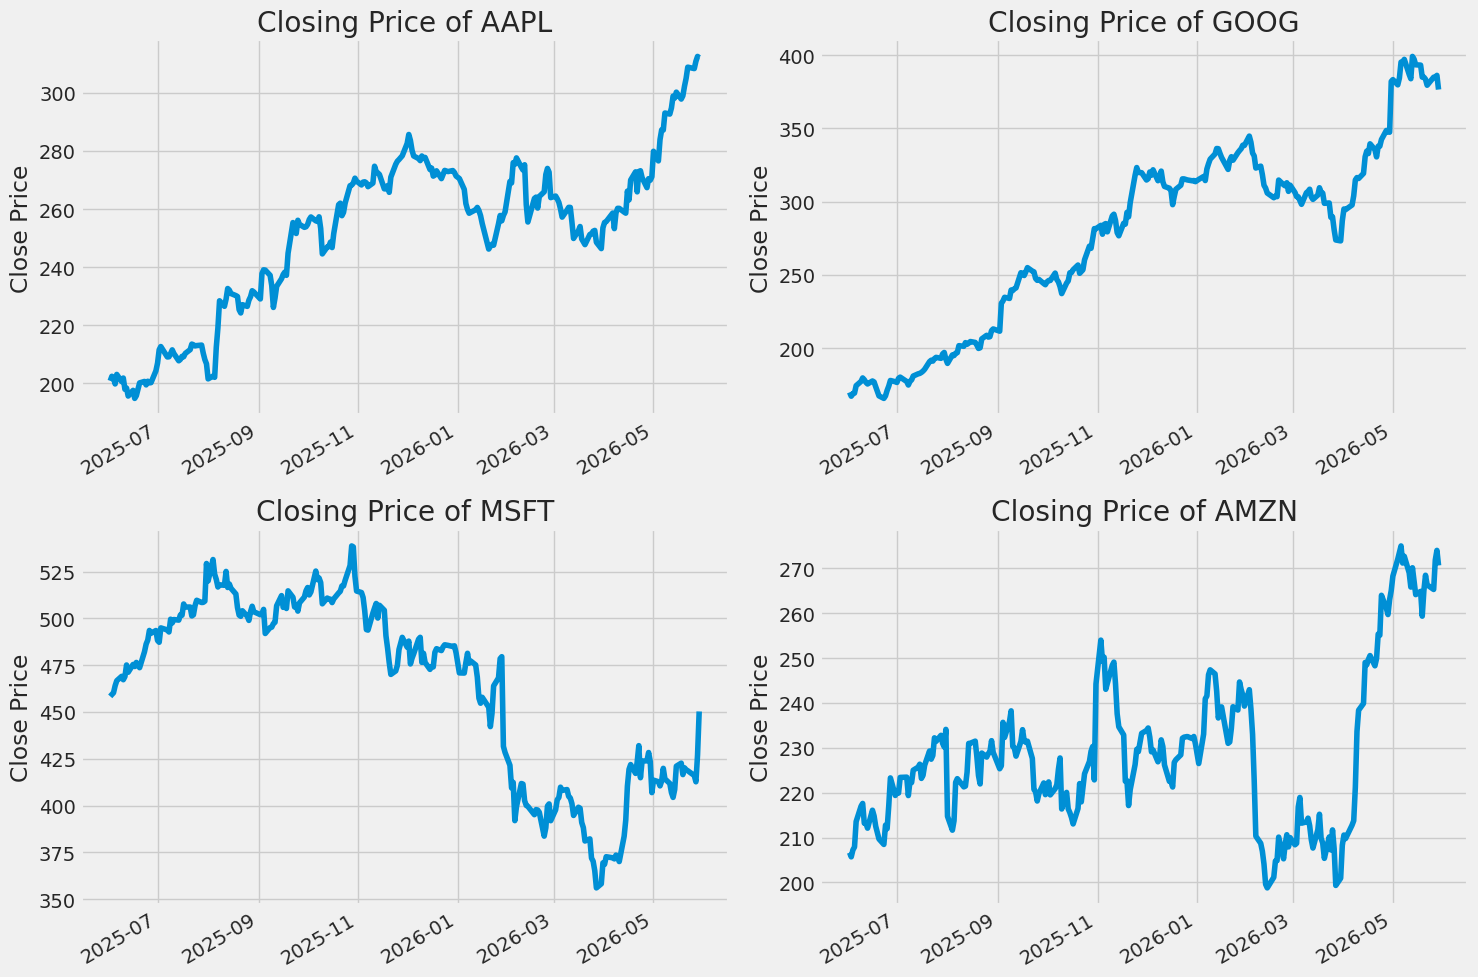

In [ ]:
# Let's see a historical view of the closing price
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    # Using 'Close' as 'Adj Close' might not be present or named differently
    company['Close'].plot()
    plt.ylabel('Close Price')
    plt.xlabel(None)
    plt.title(f"Closing Price of {tech_list[i - 1]}")

plt.tight_layout()

## Khối lượng giao dịch (Volume of Sales)
Khối lượng là lượng tài sản hoặc chứng khoán được trao tay trong một khoảng thời gian, thường là trong một ngày. Khối lượng giao dịch và sự thay đổi của nó theo thời gian là những thông số đầu vào quan trọng cho các nhà giao dịch kỹ thuật.

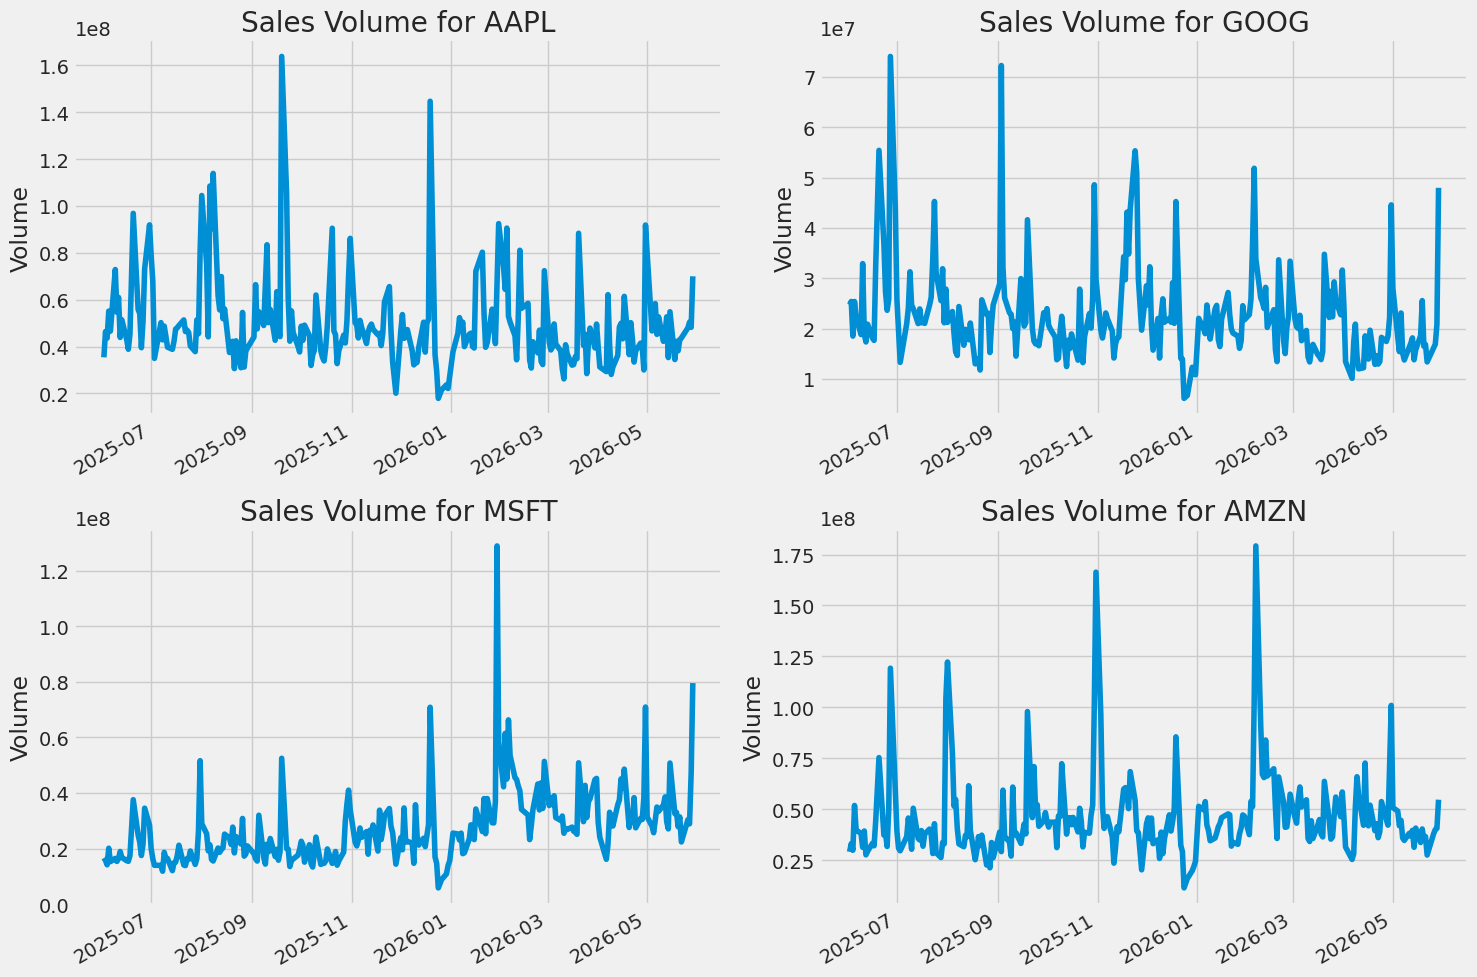

In [ ]:
# Now let's plot the total volume of stock being traded each day
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Volume'].plot()
    plt.ylabel('Volume')
    plt.xlabel(None)
    plt.title(f"Sales Volume for {tech_list[i - 1]}")

plt.tight_layout()

Sau khi xem các biểu đồ trực quan về giá đóng cửa và khối lượng giao dịch mỗi ngày, chúng ta hãy tiếp tục tính toán đường trung bình động (moving average) cho cổ phiếu.

# 2. Đường trung bình động của các cổ phiếu là gì?

Đường trung bình động (MA) là một công cụ phân tích kỹ thuật đơn giản giúp làm mượt dữ liệu giá bằng cách tạo ra một mức giá trung bình được cập nhật liên tục. Giá trung bình được tính trong một khoảng thời gian cụ thể, chẳng hạn như 10 ngày, 20 phút, 30 tuần hoặc bất kỳ khoảng thời gian nào nhà giao dịch chọn.

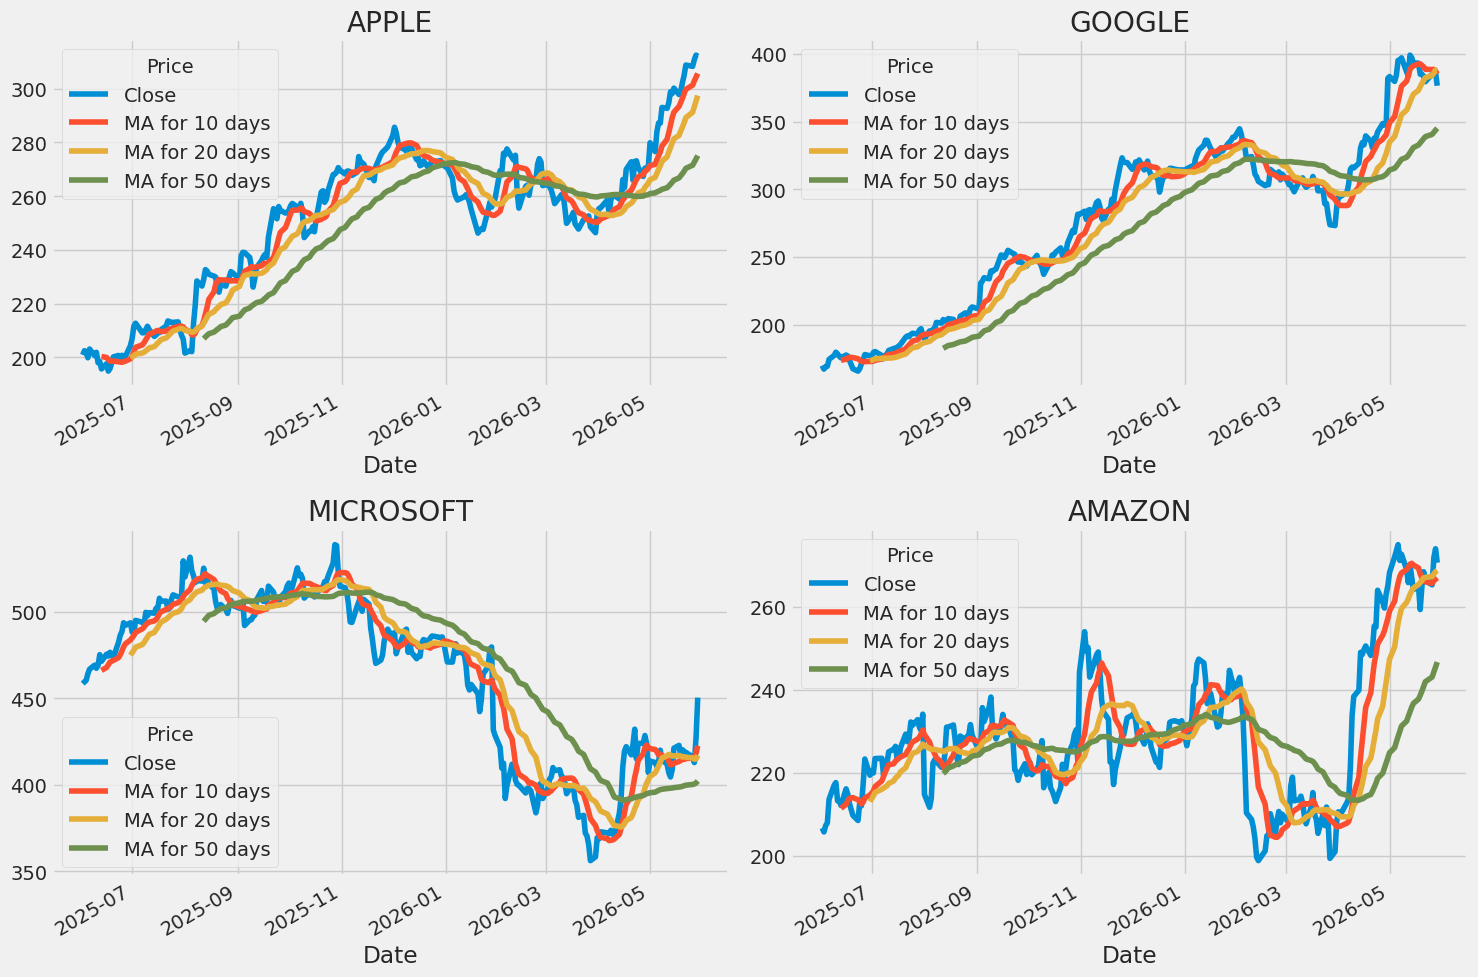

In [ ]:
ma_day = [10, 20, 50]

for ma in ma_day:
    for company in company_list:
        column_name = f"MA for {ma} days"
        company[column_name] = company['Close'].rolling(ma).mean()c

fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

AAPL[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,0])
axes[0,0].set_title('APPLE')

GOOG[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,1])
axes[0,1].set_title('GOOGLE')

MSFT[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,0])
axes[1,0].set_title('MICROSOFT')

AMZN[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,1])
axes[1,1].set_title('AMAZON')

fig.tight_layout()

Chúng ta thấy trong biểu đồ rằng các giá trị tốt nhất để đo đường trung bình động là 10 và 20 ngày vì chúng ta vẫn nắm bắt được các xu hướng trong dữ liệu mà không bị nhiễu.

# 3. Tỷ suất lợi nhuận hàng ngày trung bình của cổ phiếu là bao nhiêu?

Sau khi thực hiện một số phân tích cơ bản, hãy cùng đi sâu hơn một chút. Bây giờ chúng ta sẽ phân tích rủi ro của cổ phiếu. Để làm được điều đó, chúng ta cần xem xét kỹ hơn những thay đổi hàng ngày của cổ phiếu, chứ không chỉ là giá trị tuyệt đối của nó. Hãy sử dụng pandas để lấy tỷ suất lợi nhuận hàng ngày cho cổ phiếu Apple.

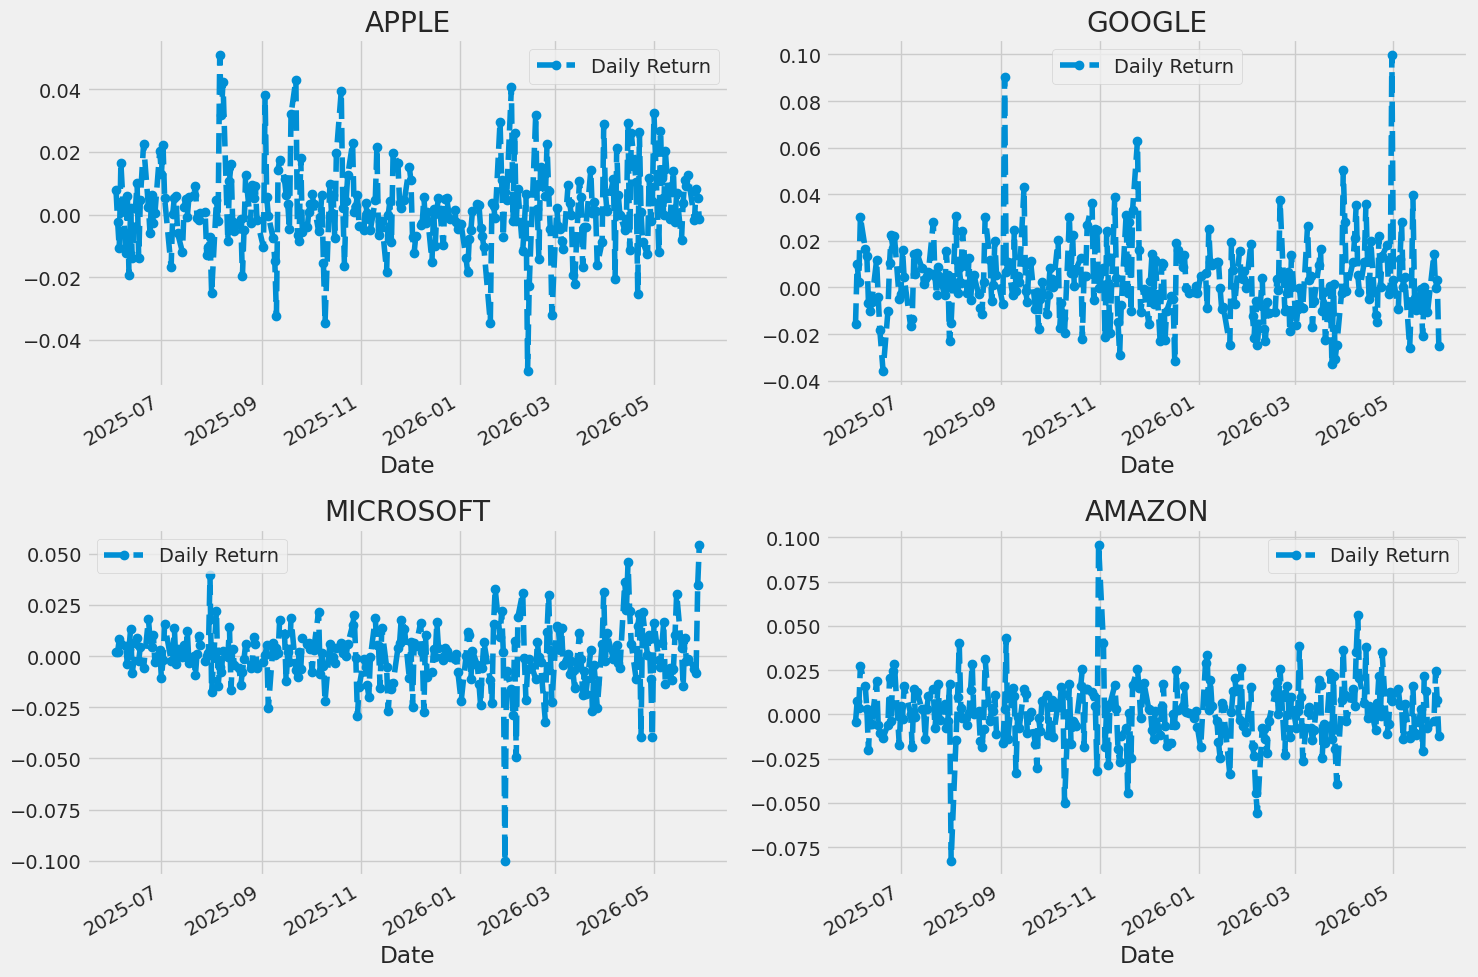

In [ ]:
for company in company_list:
    company['Daily Return'] = company['Close'].pct_change()

fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

AAPL['Daily Return'].plot(ax=axes[0,0], legend=True, linestyle='--', marker='o')
axes[0,0].set_title('APPLE')

GOOG['Daily Return'].plot(ax=axes[0,1], legend=True, linestyle='--', marker='o')
axes[0,1].set_title('GOOGLE')

MSFT['Daily Return'].plot(ax=axes[1,0], legend=True, linestyle='--', marker='o')
axes[1,0].set_title('MICROSOFT')

AMZN['Daily Return'].plot(ax=axes[1,1], legend=True, linestyle='--', marker='o')
axes[1,1].set_title('AMAZON')

fig.tight_layout()

Tuyệt vời, bây giờ hãy nhìn tổng quan về tỷ suất lợi nhuận hàng ngày trung bình bằng cách sử dụng biểu đồ histogram. Chúng ta sẽ sử dụng seaborn để tạo cả biểu đồ histogram và biểu đồ mật độ (kde plot) trên cùng một hình.

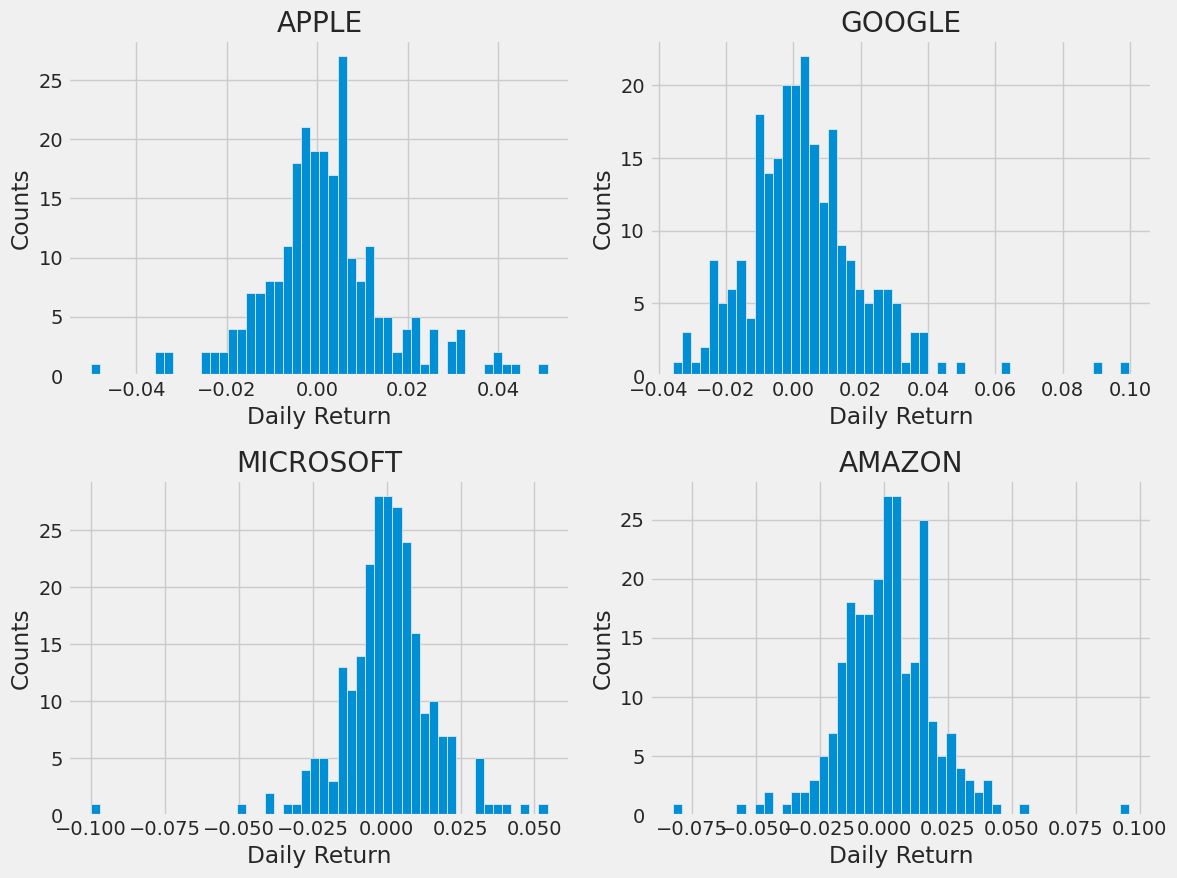

In [ ]:
plt.figure(figsize=(12, 9))

for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Daily Return'].hist(bins=50)
    plt.xlabel('Daily Return')
    plt.ylabel('Counts')
    plt.title(f'{company_name[i - 1]}')

plt.tight_layout()

# 4. Mối tương quan giữa giá đóng cửa của các cổ phiếu khác nhau?

Tương quan là một số liệu thống kê đo lường mức độ mà hai biến chuyển động cùng nhau, có giá trị nằm trong khoảng từ -1.0 đến +1.0. Tương quan đo lường sự liên kết, nhưng không cho thấy nếu x gây ra y hoặc ngược lại — hoặc liệu sự liên kết đó có do yếu tố thứ ba gây ra hay không.

Bây giờ, nếu chúng ta muốn phân tích lợi nhuận của tất cả các cổ phiếu trong danh sách? Hãy xây dựng một DataFrame với tất cả các cột ['Close'] cho mỗi dataframe cổ phiếu.

In [ ]:
closing_df = yf.download(tech_list, start=start, end=end)['Close']
tech_rets = closing_df.pct_change()
tech_rets.head()

[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,AMZN,GOOG,MSFT
Date,,,,
2025-06-02,NaN,NaN,NaN,NaN
2025-06-03,0.007784,-0.004549,-0.015613,0.002165
2025-06-04,-0.002214,0.007389,0.010017,0.001944
2025-06-05,-0.010798,0.003281,0.002479,0.008213
2025-06-06,0.016398,0.027223,0.030092,0.005773


Bây giờ chúng ta có thể so sánh tỷ lệ phần trăm lợi nhuận hàng ngày của hai cổ phiếu để kiểm tra mức độ tương quan. Đầu tiên, hãy xem một cổ phiếu khi so sánh với chính nó.

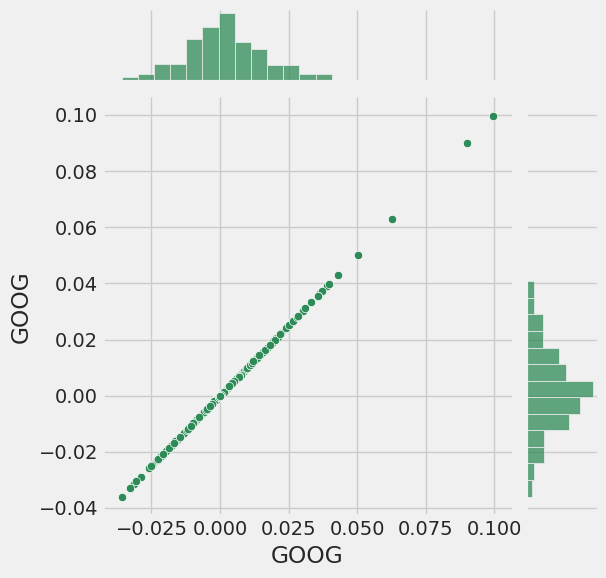

In [ ]:
# Comparing Google to itself should show a perfectly linear relationship
sns.jointplot(x='GOOG', y='GOOG', data=tech_rets, kind='scatter', color='seagreen')

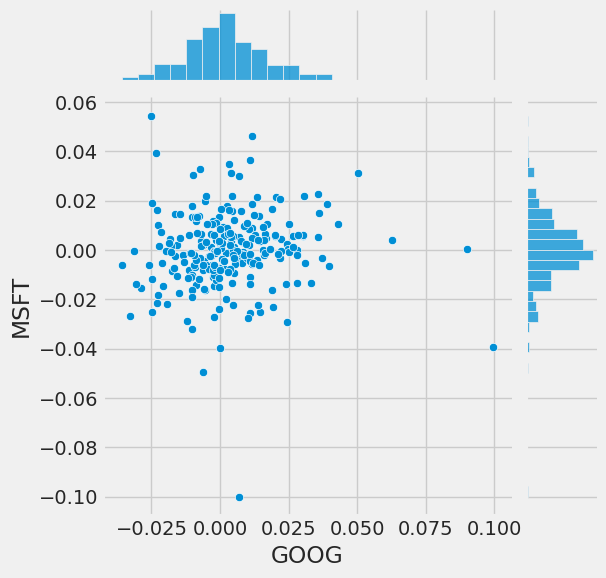

In [ ]:
# We'll use joinplot to compare the daily returns of Google and Microsoft
sns.jointplot(x='GOOG', y='MSFT', data=tech_rets, kind='scatter')

Vì vậy, bây giờ chúng ta có thể thấy rằng nếu hai cổ phiếu có tương quan hoàn hảo (và tích cực) với nhau, mối quan hệ tuyến tính giữa các giá trị lợi nhuận hàng ngày của chúng sẽ xuất hiện.

Seaborn và pandas giúp việc lặp lại phân tích so sánh này cho mọi tổ hợp cổ phiếu có thể có trong danh sách cổ phiếu công nghệ của chúng ta trở nên rất dễ dàng. Chúng ta có thể sử dụng `sns.pairplot()` để tự động tạo biểu đồ này.

/tmp/ipykernel_2640/2708808973.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  closing_df = yf.download(tech_list, start=start, end=end)['Close']
[*********************100%***********************]  4 of 4 completed


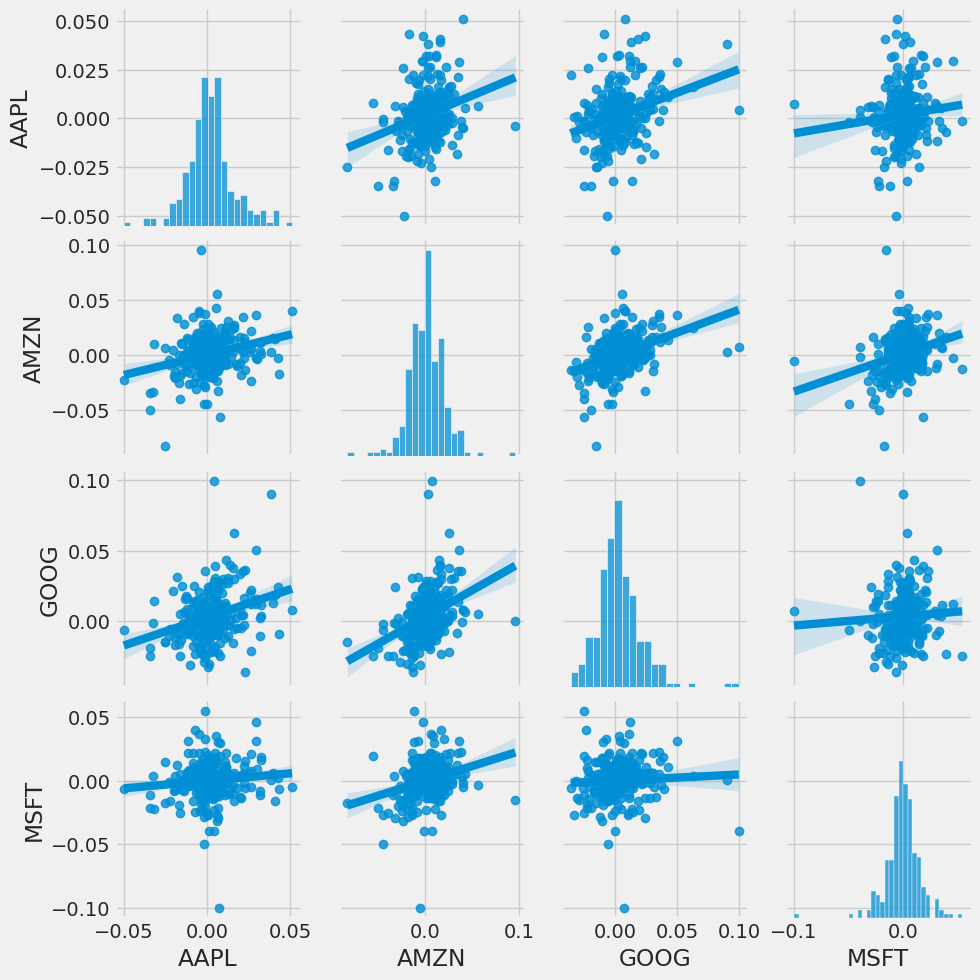

In [ ]:
closing_df = yf.download(tech_list, start=start, end=end)['Close']
tech_rets = closing_df.pct_change()

sns.pairplot(tech_rets, kind='reg')

Ở trên, chúng ta có thể thấy tất cả các mối quan hệ về lợi nhuận hàng ngày giữa tất cả các cổ phiếu. Một cái nhìn nhanh cho thấy mối tương quan thú vị giữa lợi nhuận hàng ngày của Google và Amazon. Có thể sẽ thú vị nếu điều tra so sánh riêng lẻ đó.

Mặc dù sự đơn giản của việc chỉ gọi `sns.pairplot()` là rất tuyệt vời, chúng ta cũng có thể sử dụng `sns.PairGrid()` để kiểm soát toàn bộ hình ảnh, bao gồm loại biểu đồ nào nằm ở đường chéo, tam giác trên và tam giác dưới. Dưới đây là ví dụ về việc tận dụng toàn bộ sức mạnh của seaborn để đạt được kết quả này.

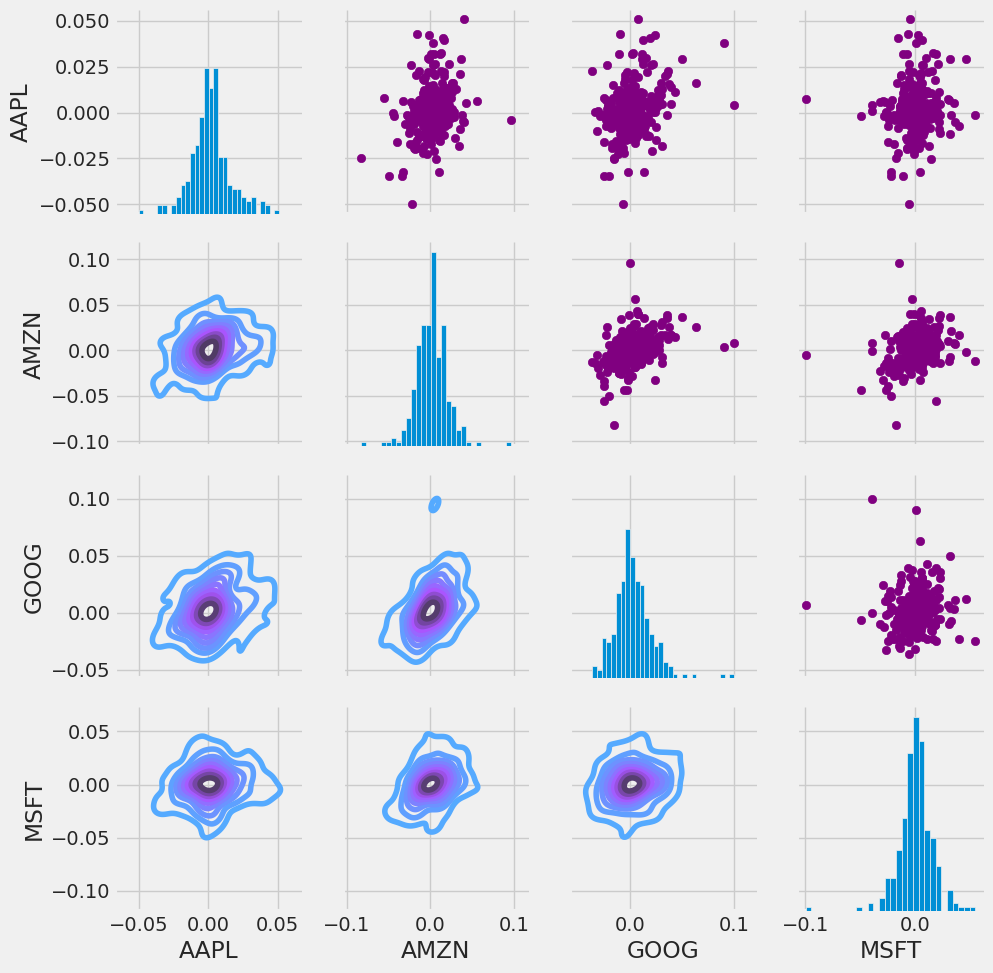

In [ ]:
# Set up our figure by naming it returns_fig, call PairPLot on the DataFrame
return_fig = sns.PairGrid(tech_rets.dropna())

# Using map_upper we can specify what the upper triangle will look like.
return_fig.map_upper(plt.scatter, color='purple')

# We can also define the lower triangle in the figure, inclufing the plot type (kde)
# or the color map (BluePurple)
return_fig.map_lower(sns.kdeplot, cmap='cool_d')

# Finally we'll define the diagonal as a series of histogram plots of the daily return
return_fig.map_diag(plt.hist, bins=30)

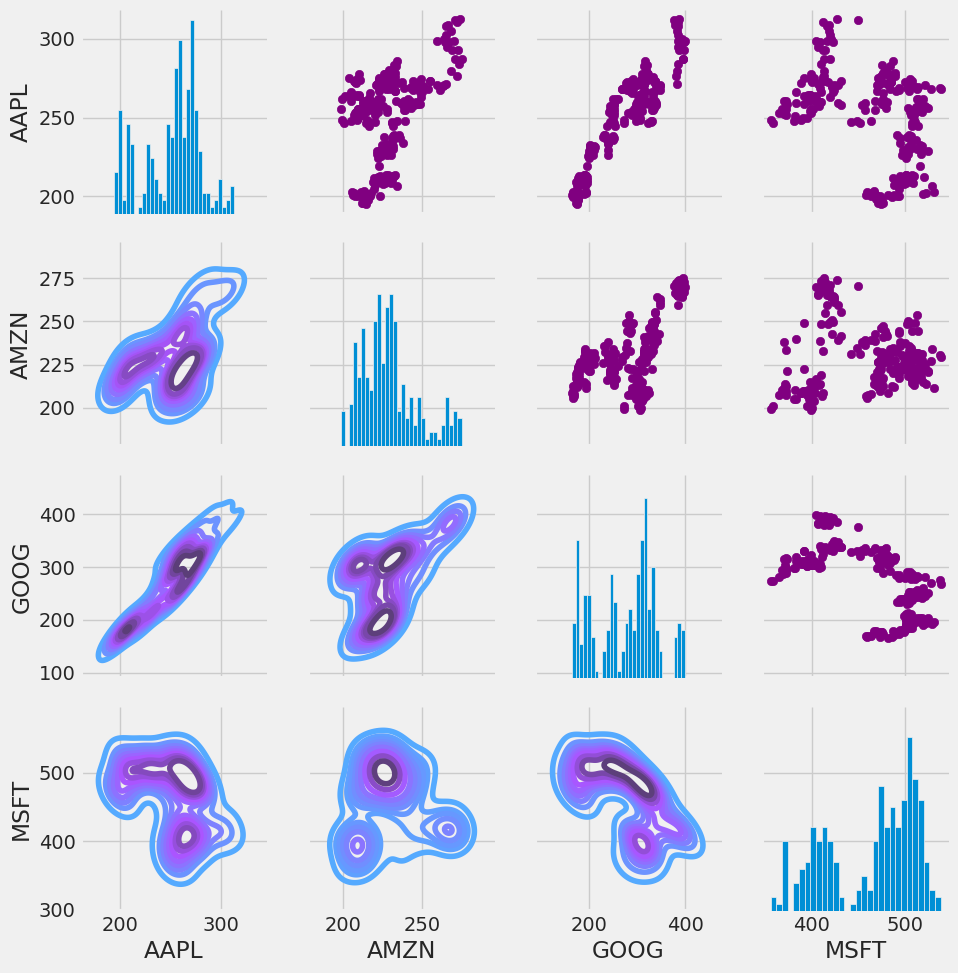

In [ ]:
# Set up our figure by naming it returns_fig, call PairPLot on the DataFrame
returns_fig = sns.PairGrid(closing_df)

# Using map_upper we can specify what the upper triangle will look like.
returns_fig.map_upper(plt.scatter,color='purple')

# We can also define the lower triangle in the figure, inclufing the plot type (kde) or the color map (BluePurple)
returns_fig.map_lower(sns.kdeplot,cmap='cool_d')

# Finally we'll define the diagonal as a series of histogram plots of the daily return
returns_fig.map_diag(plt.hist,bins=30)

Cuối cùng, chúng ta cũng có thể vẽ biểu đồ tương quan để có được các giá trị số thực tế cho mối tương quan giữa các giá trị lợi nhuận hàng ngày của các cổ phiếu. Bằng cách so sánh giá đóng cửa, chúng ta thấy một mối quan hệ thú vị giữa Microsoft và Apple.

Text(0.5, 1.0, 'Correlation of stock closing price')

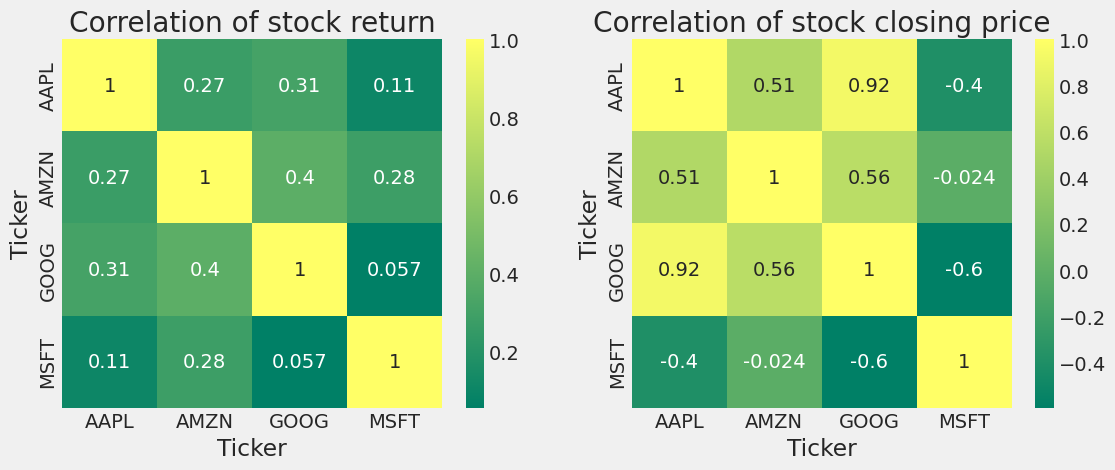

In [ ]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.heatmap(tech_rets.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock return')

plt.subplot(2, 2, 2)
sns.heatmap(closing_df.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock closing price')

Giống như chúng ta đã dự đoán trong `PairPlot`, chúng ta thấy ở đây bằng cả con số và hình ảnh rằng Microsoft và Amazon có mối tương quan mạnh nhất về lợi nhuận cổ phiếu hàng ngày. Cũng thú vị khi thấy rằng tất cả các công ty công nghệ đều có tương quan thuận (tích cực).

# 5. Chúng ta chịu rủi ro bao nhiêu khi đầu tư vào một cổ phiếu cụ thể?

Có nhiều cách chúng ta có thể định lượng rủi ro, một trong những cách cơ bản nhất sử dụng thông tin chúng ta đã thu thập được về tỷ suất lợi nhuận hàng ngày là so sánh lợi nhuận kỳ vọng với độ lệch chuẩn của lợi nhuận hàng ngày.

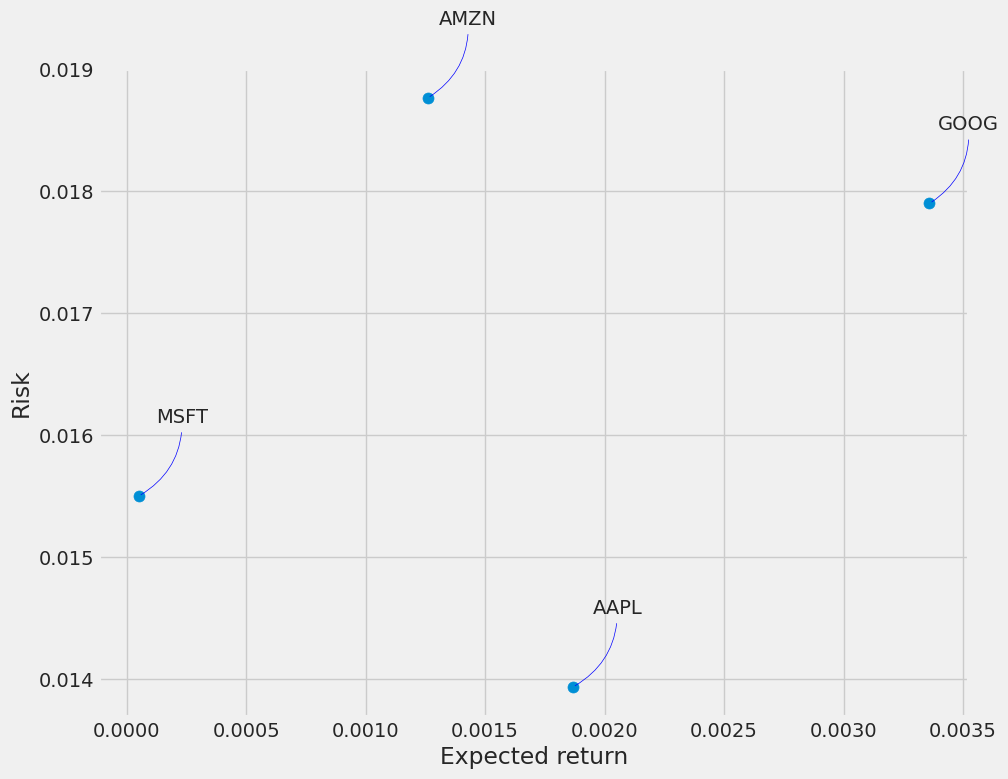

In [ ]:
rets = tech_rets.dropna()

area = np.pi * 20

plt.figure(figsize=(10, 8))
plt.scatter(rets.mean(), rets.std(), s=area)
plt.xlabel('Expected return')
plt.ylabel('Risk')

for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(label, xy=(x, y), xytext=(50, 50), textcoords='offset points', ha='right', va='bottom',
                 arrowprops=dict(arrowstyle='-', color='blue', connectionstyle='arc3,rad=-0.3'))

# 6. Dự đoán giá đóng cửa cổ phiếu của APPLE inc:

Để dự đoán giá đóng cửa của cổ phiếu Apple, chúng ta sẽ sử dụng mạng nơ-ron hồi quy dài-ngắn hạn (Long Short-Term Memory - LSTM). LSTM là một loại mạng nơ-ron hồi quy (RNN) đặc biệt, có khả năng học và ghi nhớ các phụ thuộc dài hạn trong dữ liệu chuỗi thời gian, rất phù hợp cho việc dự đoán giá cổ phiếu dựa trên dữ liệu lịch sử.

In [ ]:
# Lấy báo giá cổ phiếu bằng yfinance thay vì pandas_datareader
df = yf.download('AAPL', start='2012-01-01', end=datetime.now())

# Nếu kết quả trả về có MultiIndex (do yfinance mới), ta làm phẳng nó
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Hiển thị dữ liệu
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2012-01-03,12.310346,12.348364,12.243590,12.255565,302220800
2012-01-04,12.376500,12.413621,12.251969,12.273522,260022000
2012-01-05,12.513907,12.529473,12.353453,12.421707,271269600
2012-01-06,12.644726,12.655203,12.549531,12.565996,318292800
2012-01-09,12.624667,12.804879,12.613291,12.737524,394024400
...,...,...,...,...,...
2026-05-22,308.820007,311.399994,305.839996,306.119995,43670200
2026-05-26,308.329987,311.820007,307.670013,309.559998,48000500
2026-05-27,310.850006,313.260010,308.299988,308.329987,50430900


Đoạn mã này tải lại dữ liệu giá cổ phiếu của Apple từ năm 2012 đến nay. Việc này đảm bảo chúng ta có một tập dữ liệu lớn và đầy đủ cho việc huấn luyện mô hình dự đoán. `df.columns = df.columns.get_level_values(0)` được sử dụng để làm phẳng MultiIndex nếu có, giúp dễ dàng truy cập các cột dữ liệu.

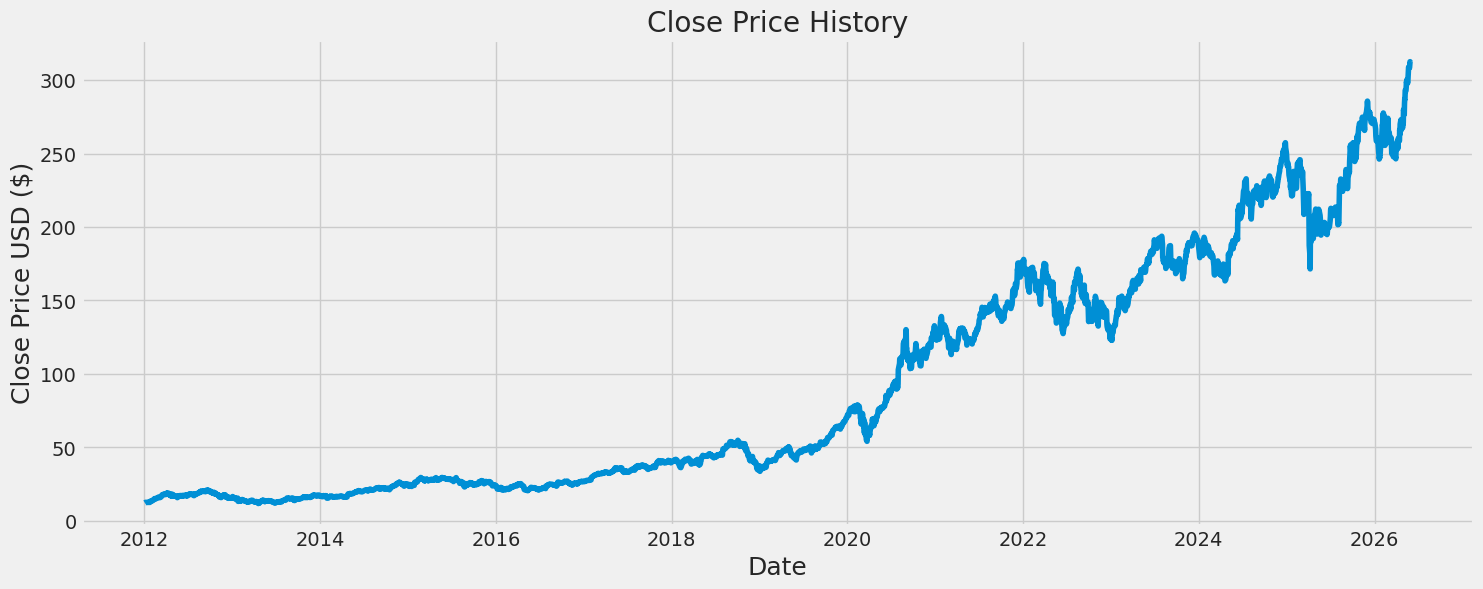

In [ ]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

Trước khi xây dựng mô hình LSTM, chúng ta cần chuẩn bị dữ liệu. Bước này bao gồm:  
- **Trích xuất cột 'Close':** Chúng ta chỉ quan tâm đến giá đóng cửa để dự đoán.  
- **Chia dữ liệu thành tập huấn luyện và kiểm tra:** 95% dữ liệu được sử dụng để huấn luyện mô hình, 5% còn lại để kiểm tra hiệu suất của mô hình.  
- **Chuẩn hóa dữ liệu:** LSTM hoạt động tốt hơn với dữ liệu được chuẩn hóa trong khoảng từ 0 đến 1. `MinMaxScaler` được sử dụng để thực hiện việc này.

In [ ]:
# Create a new dataframe with only the 'Close column
data = df.filter(['Close'])
# Convert the dataframe to a numpy array
dataset = data.values
# Get the number of rows to train the model on

# Sử dụng 95% data để train model

training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len

3441

In [ ]:
# Scale the data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.00148714],
       [0.00170718],
       [0.00216422],
       ...,
       [0.99447856],
       [1.        ],
       [0.99850319]])

Bước này tạo ra các tập dữ liệu huấn luyện `x_train` và `y_train`.  
- `x_train` chứa các chuỗi 60 giá đóng cửa trước đó, được sử dụng làm đầu vào để dự đoán giá đóng cửa tiếp theo.  
- `y_train` chứa giá đóng cửa tại thời điểm tiếp theo, là mục tiêu mà mô hình cần học cách dự đoán.  
Dữ liệu sau đó được **định hình lại** (reshape) để phù hợp với định dạng đầu vào của LSTM (số lượng mẫu, số bước thời gian, số lượng tính năng).

In [ ]:
# Create the training data set
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()

# Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_train.shape

[array([0.00148714, 0.00170718, 0.00216422, 0.00259934, 0.00253263,
       0.00268296, 0.00261427, 0.00249878, 0.00234145, 0.00282835,
       0.00326745, 0.00313205, 0.00239024, 0.00309819, 0.00240119,
       0.00501491, 0.00481278, 0.00507665, 0.00564718, 0.00599269,
       0.00596381, 0.00585727, 0.00631132, 0.00673847, 0.00722237,
       0.00800401, 0.00964591, 0.00967082, 0.01058486, 0.01126792,
       0.01009397, 0.01054603, 0.01053706, 0.01180458, 0.01162438,
       0.01195792, 0.01255732, 0.01289089, 0.01385176, 0.01455172,
       0.01475385, 0.01482456, 0.01362771, 0.01333896, 0.01338179,
       0.01450692, 0.01482356, 0.01550362, 0.01710671, 0.01924545,
       0.01884521, 0.0188462 , 0.0203925 , 0.02087645, 0.02053191,
       0.02021725, 0.01988969, 0.02097801, 0.02172475, 0.02203741])]
[np.float64(0.021264745544681662)]

[array([0.00148714, 0.00170718, 0.00216422, 0.00259934, 0.00253263,
       0.00268296, 0.00261427, 0.00249878, 0.00234145, 0.00282835,
       0.00326745, 0.0

Đây là nơi mô hình LSTM được xây dựng và huấn luyện:  
- **`Sequential()`:** Khởi tạo một mô hình tuần tự.  
- **`LSTM(128, return_sequences=True, input_shape=(x_train.shape[1], 1))`:** Lớp LSTM đầu tiên với 128 đơn vị. `return_sequences=True` để lớp LSTM tiếp theo có thể nhận đầu ra chuỗi. `input_shape` xác định kích thước đầu vào.  
- **`LSTM(64, return_sequences=False)`:** Lớp LSTM thứ hai với 64 đơn vị. `return_sequences=False` vì đây là lớp LSTM cuối cùng và chúng ta muốn đầu ra là một giá trị duy nhất (giá đóng cửa dự đoán).  
- **`Dense(25)` và `Dense(1)`:** Các lớp dày đặc (fully connected) để chuyển đổi đầu ra của LSTM thành dự đoán giá đóng cửa cuối cùng. Lớp cuối cùng có 1 đơn vị vì chúng ta dự đoán một giá trị duy nhất.  
- **`model.compile(optimizer='adam', loss='mean_squared_error')`:** Biên dịch mô hình, sử dụng trình tối ưu hóa Adam và hàm mất mát sai số bình phương trung bình (MSE).  
- **`model.fit(x_train, y_train, batch_size=1, epochs=1)`:** Huấn luyện mô hình trên dữ liệu huấn luyện. `batch_size=1` có nghĩa là mô hình sẽ cập nhật trọng số sau mỗi mẫu dữ liệu. `epochs=1` có nghĩa là mô hình sẽ duyệt qua toàn bộ tập dữ liệu huấn luyện một lần.

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3381/3381 ━━━━━━━━━━━━━━━━━━━━ 163s 46ms/step - loss: 8.7891e-04


Sau khi huấn luyện, chúng ta đánh giá hiệu suất của mô hình trên tập dữ liệu kiểm tra:  
- **`test_data`:** Chuẩn bị dữ liệu kiểm tra tương tự như dữ liệu huấn luyện.  
- **`model.predict(x_test)`:** Sử dụng mô hình đã huấn luyện để đưa ra dự đoán trên `x_test`.  
- **`scaler.inverse_transform(predictions)`:** Chuyển đổi ngược các dự đoán đã chuẩn hóa về thang đo ban đầu để có được giá trị giá thực tế.  
- **`rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))`:** Tính toán sai số bình phương trung bình gốc (RMSE), một thước đo phổ biến cho thấy mức độ chính xác của mô hình dự đoán. RMSE càng nhỏ, mô hình càng chính xác.

In [ ]:
# Create the testing data set
# Create a new array containing scaled values from index 1543 to 2002
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step


np.float64(9.580822701889678)

Cuối cùng, đoạn mã này trực quan hóa kết quả:  
- Nó vẽ biểu đồ giá đóng cửa thực tế (`Close`) của tập huấn luyện và tập kiểm tra, cùng với các dự đoán của mô hình (`Predictions`) trên tập kiểm tra.  
- Điều này giúp chúng ta so sánh trực quan hiệu suất của mô hình: mức độ khớp giữa giá đóng cửa thực tế và giá đóng cửa được dự đoán.

/tmp/ipykernel_4426/2388977846.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


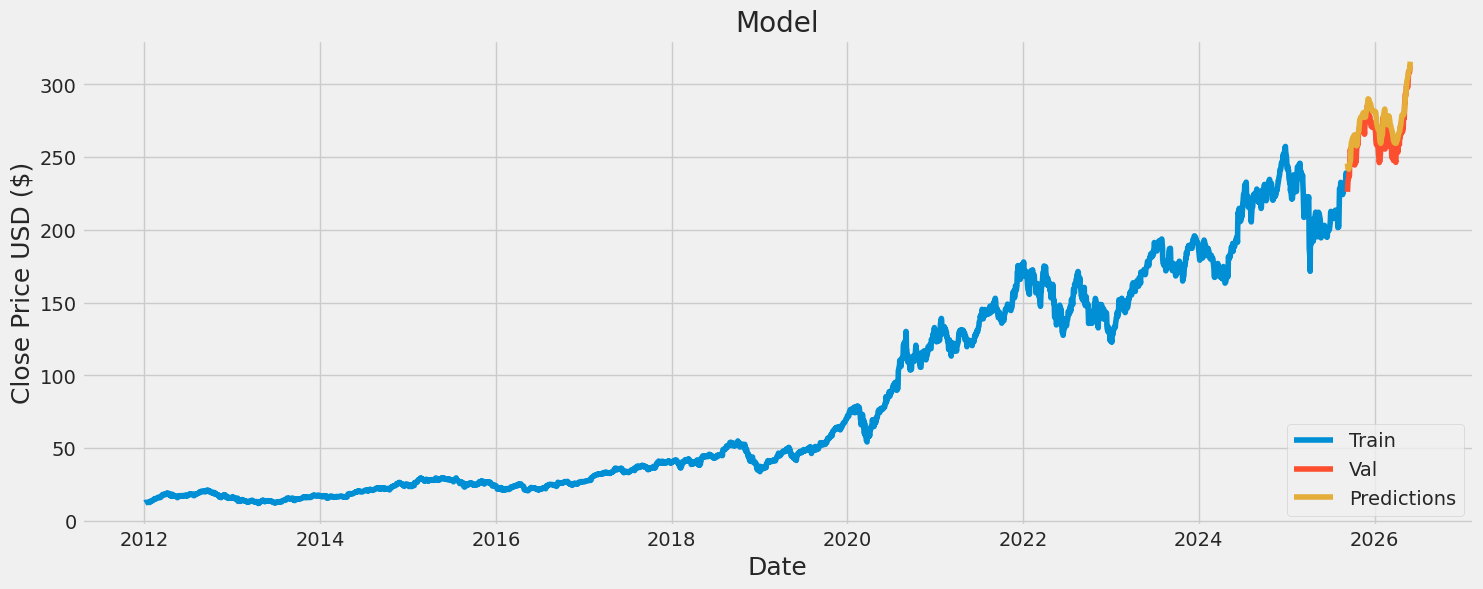

In [ ]:
# Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

Biểu đồ này cho phép chúng ta nhìn rõ hơn các giá trị dự đoán so với giá trị thực tế trên tập dữ liệu kiểm tra.

In [ ]:
# Show the valid and predicted prices
valid

,Close,Predictions
Date,,
2025-09-10,226.150192,245.600266
2025-09-11,229.381058,243.774582
2025-09-12,233.409668,242.195602
2025-09-15,236.032242,241.694183
2025-09-16,237.478149,242.174423
...,...,...
2026-05-22,308.820007,308.247955
2026-05-26,308.329987,310.283752
2026-05-27,310.850006,312.052826


# Tổng kết
Trong notebook này, bạn đã khám phá và phân tích dữ liệu cổ phiếu.

Cụ thể, bạn đã học được:

- Cách tải dữ liệu thị trường chứng khoán từ Yahoo Finance bằng yfinance.
- Cách khám phá và trực quan hóa dữ liệu chuỗi thời gian bằng Pandas, Matplotlib và Seaborn.
- Cách đo lường mối tương quan giữa các cổ phiếu.
- Cách đo lường rủi ro khi đầu tư vào một cổ phiếu cụ thể.

# Đóng góp
Đồ án LSTM Python dự đoán giá cổ phiếu được thực hiện & đóng góp bởi những thành viên của nhóm.

Danh sách thành viên & phân công:

- Lê Đỗ Quang Dũng - 2001230099: Phân công công việc, tìm hiểu thuật toán (100%)
- Đặng Đình Sơn - 2001230234: Tìm hiểu thuật toán, phát triển mô hình (100%)
- Vũ Mạnh Hiệp - 2001230234: Tìm hiểu thuật toán, nghiên cứu Data (100%)
- Giêng Phát Ninh - 2033230143: Tìm hiểu thuật toán, phát triển mô hình (100%)